In [31]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import pandas
from itertools import product
import networkx as nx
import matplotlib.pyplot as plt
import pickle

In [32]:
# def create_list(n_total: int, n: int):
#     return [1] * n + [0] * (n_total - n)

In [33]:
def create_list(n_total: int, n_start: int = 0, n_end: int = 0, disrupt_val:float=0.0) -> list:
    n_start = n_start or n_total
    n_end = n_end or n_total
    return [1] * n_start + [disrupt_val] * (n_end - n_start) + [1] * (n_total - n_end)

In [34]:
def create_event_dict(n_total: int):
    # If event names are same before '_'; they are considered mutually exclusive
    event_dict = {
        'cap2_1': {'prob': 0.06, 'factor': pandas.DataFrame(data={('loc2', 'com1_process'): create_list(n_total, 13)})},
        'cap2_2': {'prob': 0.12, 'factor': pandas.DataFrame(data={('loc2', 'com1_process'): create_list(n_total, 26)})},
        'cap2_3': {'prob': 0.17, 'factor': pandas.DataFrame(data={('loc2', 'com1_process'): create_list(n_total, 39)})},
        'cap2_nd': {'prob': 0.65, 'factor': pandas.DataFrame(data={('loc2', 'com1_process'): create_list(n_total)})},

        'cap7_1': {'prob': 0.04, 'factor': pandas.DataFrame(data={('loc7', 'com1_process'): create_list(n_total, 13)})},
        'cap7_2': {'prob': 0.15, 'factor': pandas.DataFrame(data={('loc7', 'com1_process'): create_list(n_total, 26)})},
        'cap7_3': {'prob': 0.2, 'factor': pandas.DataFrame(data={('loc7', 'com1_process'): create_list(n_total, 39)})},
        'cap7_nd': {'prob': 0.61, 'factor': pandas.DataFrame(data={('loc7', 'com1_process'): create_list(n_total)})},

        'res6_1': {'prob': 0.03, 'factor': pandas.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total, 13)})},
        'res6_2': {'prob': 0.16, 'factor': pandas.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total, 26)})},
        'res6_3': {'prob': 0.17, 'factor': pandas.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total, 39)})},
        'res6_nd': {'prob': 0.64, 'factor': pandas.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total)})},

        'truck25_1': {'prob': 0.3, 'factor': pandas.DataFrame(data={('truck25', 'com1_loc2_out'): create_list(n_total, 13)})},
        'truck25_nd': {'prob': 0.7, 'factor': pandas.DataFrame(data={('truck25', 'com1_loc2_out'): create_list(n_total)})},

        # 'truck45_1': {'prob': 0.05, 'factor': pandas.DataFrame(data={('truck45', 'com1_loc4_out'): create_list(n_total, 13, 26, 0.75)})},
        'truck45_2': {'prob': 0.45, 'factor': pandas.DataFrame(data={('truck45', 'com1_loc4_out'): create_list(n_total, 26, 39, 0.5)})},
        # 'truck45_3': {'prob': 0.15, 'factor': pandas.DataFrame(data={('truck45', 'com1_loc4_out'): create_list(n_total, 39, 52, 0.25)})},
        'truck45_nd': {'prob': 0.55, 'factor': pandas.DataFrame(data={('truck45', 'com1_loc4_out'): create_list(n_total)})}
    }

    return event_dict

In [35]:
# Function to generate the scenario dictionary for n sets of events
def create_scenario_dict(event_dict):
    # Extract unique event prefixes (e.g., 'cap2', 'cap4', ...)
    event_prefixes = set(key.split('_')[0] for key in event_dict)

    # Group events by their prefixes
    grouped_events = {prefix: [key for key in event_dict if key.startswith(prefix)] for prefix in event_prefixes}

    # Create all possible combinations of events across the different groups
    event_combinations = list(product(*grouped_events.values()))

    scenario_dict = {}

    # Iterate over all event combinations
    for combination in event_combinations:
        # Construct the scenario key
        scenario_key = ' '.join(combination)

        # Calculate the probability of this scenario
        prob = 1
        combined_factor = None

        for event_key in combination:
            # Multiply probabilities
            prob *= event_dict[event_key]['prob']

            # Combine factors (assumes they are pandas DataFrames)
            if combined_factor is None:
                combined_factor = event_dict[event_key]['factor'].copy()
            else:
                combined_factor = combined_factor.add(event_dict[event_key]['factor'], fill_value=0)

        # Add to the scenario dictionary
        scenario_dict[scenario_key] = {'prob': prob, 'factor': combined_factor}

    return scenario_dict

In [36]:
def plot_bn_tree(model):
    """
    Plots the Bayesian network structure and annotates each node
    with its marginal probabilities of all states.
    """
    # Perform inference to compute marginals
    infer = VariableElimination(model)
    
    marginals = {}
    for node in model.nodes():
        q = infer.query(variables=[node])
        state_names = q.state_names[node]
        probs = q.values
        # Format label like: "cap2\ncap2_1:0.06\ncap2_2:0.12..."
        label = f"{node}\n" + "\n".join(
            [f"{s.split('_')[-1]}: {p:.2f}" for s, p in zip(state_names, probs)]
        )
        marginals[node] = label

    # Draw structure
    G = nx.DiGraph(model.edges())
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(8,6))
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size=3000,
        node_color="lightblue",
        edgecolors="black",
        arrowsize=20
    )

    # Draw labels with probabilities
    for node, (x, y) in pos.items():
        plt.text(
            x,
            y,
            marginals[node],
            ha='center',
            va='center',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.8)
        )

    plt.title("Bayesian Scenario Structure with Node Probabilities", fontsize=12)
    plt.axis('off')
    plt.show()


In [37]:
model = DiscreteBayesianNetwork([('truck45', 'cap2')])

In [38]:
model.add_nodes_from(['cap7', 'res6', 'truck25'])

In [39]:
cpd_truck45 = TabularCPD(
    variable='truck45',
    variable_card=2,
    values=[[0.45], [0.55]],
    state_names={'truck45': ['truck45_2', 'truck45_nd']}
)

In [40]:
cpd_cap7 = TabularCPD(
    variable='cap7',
    variable_card=4,
    values=[[0.04], [0.15], [0.2], [0.61]],
    state_names={'cap7': ['cap7_1', 'cap7_2', 'cap7_3', 'cap7_nd']}
)

In [41]:
cpd_res6 = TabularCPD(
    variable='res6',
    variable_card=4,
    values=[[0.03], [0.16], [0.17], [0.64]],
    state_names={'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd']}
)

In [42]:
cpd_truck25 = TabularCPD(
    variable='truck25',
    variable_card=2,
    values=[[0.3], [0.7]],
    state_names={'truck25': ['truck25_1', 'truck25_nd']}
)

In [43]:
cpd_cap2 = TabularCPD(
    variable='cap2',
    variable_card=4,
    values=[
        [0.03, 0.06],
        [0.27, 0.12],
        [0.50, 0.17],
        [0.20, 0.65]
    ],
    evidence=['truck45'],
    evidence_card=[2],
    state_names={
        'cap2': ['cap2_1', 'cap2_2', 'cap2_3', 'cap2_4'],
        'truck45': ['truck45_2', 'truck45_nd']
    }
)

In [44]:
model.add_cpds(cpd_truck45, cpd_cap7, cpd_truck25, cpd_cap2, cpd_res6)

In [45]:
# # Define Bayesian structure
# model = DiscreteBayesianNetwork([
#     ('res6', 'truck25'),
#     ('cap7', 'truck25'),
#     ('res6', 'cap7')
# ])
# cpd_res6 = TabularCPD(
#     variable='res6',
#     variable_card=4,
#     values=[[0.03], [0.16], [0.17], [0.64]],
#     state_names={'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd']}
# )
# # cap7 depends on res6
# cpd_cap7 = TabularCPD(
#     variable='cap7',
#     variable_card=4,
#     values=[
#         [0.06, 0.04, 0.04, 0.04],   # P(cap7_1 | res6_i)
#         [0.2, 0.18, 0.15, 0.15],    # P(cap7_2 | res6_i)
#         [0.25, 0.23, 0.22, 0.2],
#         [0.49, 0.55, 0.59, 0.61]
#     ],
#     evidence=['res6'],
#     evidence_card=[4],
#     state_names={
#         'cap7': ['cap7_1', 'cap7_2', 'cap7_3', 'cap7_nd'],
#         'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd']
#     }
# )
# cpd_truck25 = TabularCPD(
#     variable='truck25',
#     variable_card=2,
#     values=[
#         # P(truck25_1 | each (res6,cap7) combination)
#         [0.7, 0.3, 0.3, 0.3,  0.5, 0.3, 0.3, 0.3,  0.5, 0.3, 0.3, 0.3,  0.5, 0.3, 0.3, 0.3],
#         # P(truck45_nd | ...) = 1 - above
#         [0.3, 0.7, 0.7, 0.7,  0.5, 0.7, 0.7, 0.7,  0.5, 0.7, 0.7, 0.7,  0.5, 0.7, 0.7, 0.7],
#     ],
#     evidence=['res6', 'cap7'],
#     evidence_card=[4, 4],
#     state_names={
#         'truck25': ['truck25_1', 'truck25_nd'],
#         'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd'],
#         'cap7': ['cap7_1', 'cap7_2', 'cap7_3', 'cap7_nd'],
#     }
# )
# model.add_cpds(cpd_cap7, cpd_truck25, cpd_res6)

In [46]:
assert model.check_model()

In [47]:
inference = VariableElimination(model)

In [48]:
joint = inference.query(variables=['truck45', 'cap2', 'cap7', 'truck25', 'res6'], joint=True)

In [49]:
joint_values = joint.values.flatten()
joint_states = joint.state_names

In [50]:
def build_scenario_dict_from_bn(joint, event_dict):
    scenario_dict = {}
    state_names = list(joint.state_names.keys())
    all_states = product(*joint.state_names.values())

    for idx, states in enumerate(all_states):
        scenario_key = ' '.join(states)
        prob = joint.values.flatten()[idx]

        # Combine relevant factors
        combined_factor = None
        for s in states:
            if s in event_dict:
                f = event_dict[s]['factor']
                combined_factor = f.copy() if combined_factor is None else combined_factor.add(f, fill_value=0)

        scenario_dict[scenario_key] = {'prob': prob, 'factor': combined_factor}

    return scenario_dict

In [51]:
event_dict = create_event_dict(52)
bayesian_scenario_dict = build_scenario_dict_from_bn(joint, event_dict)

In [52]:
scenario_dict = create_scenario_dict(event_dict=event_dict)

In [53]:
len(list(bayesian_scenario_dict.keys()))

256

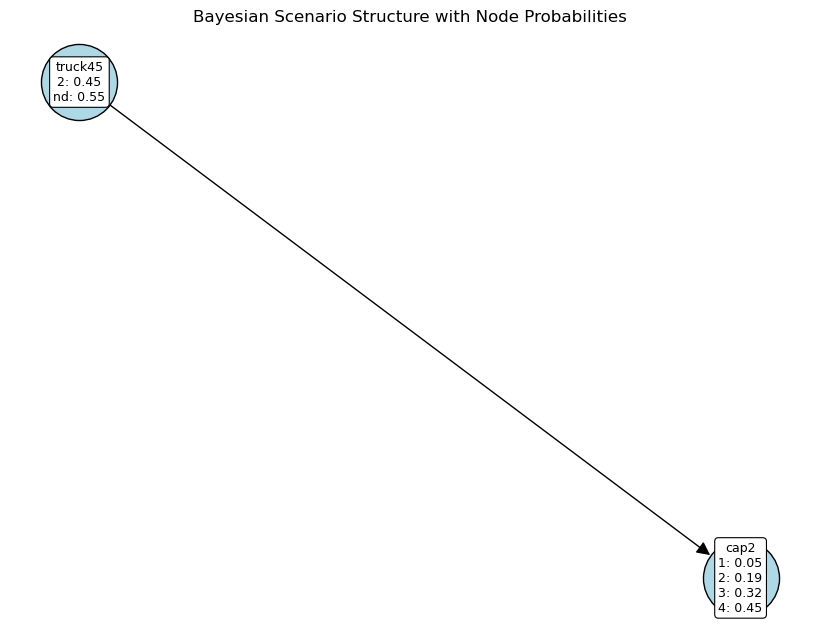

In [54]:
plot_bn_tree(model)

In [55]:
for k, v in bayesian_scenario_dict.items():
    print(k, v['prob'])

truck45_2 cap2_1 cap7_1 truck25_1 res6_1 4.859999999999999e-06
truck45_2 cap2_1 cap7_1 truck25_1 res6_2 2.592e-05
truck45_2 cap2_1 cap7_1 truck25_1 res6_3 2.754e-05
truck45_2 cap2_1 cap7_1 truck25_1 res6_nd 0.00010368
truck45_2 cap2_1 cap7_1 truck25_nd res6_1 1.134e-05
truck45_2 cap2_1 cap7_1 truck25_nd res6_2 6.0480000000000004e-05
truck45_2 cap2_1 cap7_1 truck25_nd res6_3 6.426000000000001e-05
truck45_2 cap2_1 cap7_1 truck25_nd res6_nd 0.00024192000000000001
truck45_2 cap2_1 cap7_2 truck25_1 res6_1 1.8225e-05
truck45_2 cap2_1 cap7_2 truck25_1 res6_2 9.719999999999999e-05
truck45_2 cap2_1 cap7_2 truck25_1 res6_3 0.000103275
truck45_2 cap2_1 cap7_2 truck25_1 res6_nd 0.00038879999999999996
truck45_2 cap2_1 cap7_2 truck25_nd res6_1 4.2525e-05
truck45_2 cap2_1 cap7_2 truck25_nd res6_2 0.0002268
truck45_2 cap2_1 cap7_2 truck25_nd res6_3 0.00024097500000000002
truck45_2 cap2_1 cap7_2 truck25_nd res6_nd 0.0009072
truck45_2 cap2_1 cap7_3 truck25_1 res6_1 2.4299999999999998e-05
truck45_2 cap2_

In [60]:
# for k, v in scenario_dict.items():
#     print(k, v['prob'])

In [57]:
# with open('backlog_bayesian_scen_dict_cl_step3.pkl', 'wb') as file:
#     pickle.dump(bayesian_scenario_dict, file)
# 
# # print(*scenario_names, sep='\n')
# print(f"Sum of probabilities of all scenarios: {sum(bayesian_scenario_dict[scen]['prob'] for scen in bayesian_scenario_dict):.6f}")
# print(f'Number of considered scenarios: {len(bayesian_scenario_dict.keys())}')

Sum of probabilities of all scenarios: 1.000000
Number of considered scenarios: 256


In [58]:
with open('backlog_bayesian_scen_dict_cl_step3.pkl', 'rb') as file:
    load_bayesian_scenario_dict_cl_step3 = pickle.load(file)

# print(*scenario_names, sep='\n')
print(f"Sum of probabilities of all scenarios: {sum(load_bayesian_scenario_dict_cl_step3[scen]['prob'] for scen in bayesian_scenario_dict):.6f}")
print(f'Number of considered scenarios: {len(load_bayesian_scenario_dict_cl_step3.keys())}')

Sum of probabilities of all scenarios: 1.000000
Number of considered scenarios: 256
